# Imporant pixels

You are given a pipeline that trains a fully convolutional autoencoder on the MNIST dataset. The model should train in under 2 minutes and give decent results (mean reconstruction loss <35).

Your task is to write a function that for a given input image and output pixel coordinates produces a list of input pixels that have non-zero contribution to the value of the output pixel. You should measure each pixel's contribution by setting it to the minimal and maximal value over the whole image.


Training pipeline (DO NOT CHANGE THIS SECTION)

In [1]:
import typing
import os
import random
import numpy as np
import torch
import torchvision
import torch.nn.functional as F
from torch import nn
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import MNIST
import matplotlib.pyplot as plt

np.random.seed(0)
torch.manual_seed(0)
random.seed(0)

In [2]:
epochs = 5
batch_size = 250
learning_rate = 1e-2
log_interval = 40

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class Binarize:
    def __call__(self, sample):
        return torch.bernoulli(sample)

img_transform = transforms.Compose([
    transforms.ToTensor(),
    Binarize(),
    transforms.Normalize([0.5], [0.5])
])

train = MNIST('./data', train=True, transform=img_transform, download=True)
train_loader = DataLoader(train, batch_size=batch_size, shuffle=True)

test = MNIST('./data', train=False, transform=img_transform, download=True)
test_loader = DataLoader(test, batch_size=batch_size, shuffle=True)

100%|██████████| 9.91M/9.91M [00:14<00:00, 686kB/s] 
100%|██████████| 28.9k/28.9k [00:00<00:00, 168kB/s]
100%|██████████| 1.65M/1.65M [00:02<00:00, 705kB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 1.36MB/s]


In [4]:
class FCN(nn.Module):
    def __init__(self):
        super(FCN, self).__init__()
        self.encoder = nn.Sequential(
        nn.Conv2d(
            1,
            16,
            kernel_size=(3, 3),
            padding=1,
            stride=1,
            bias=False,
        ),
        nn.BatchNorm2d(16),
        nn.LeakyReLU(),
        nn.Conv2d(
            16,
            32,
            kernel_size=(4, 4),
            padding=1,
            stride=2,
            bias=False,),
        nn.BatchNorm2d(32),
        nn.LeakyReLU(),
        nn.Conv2d(
            32,
            64,
            kernel_size=(4, 4),
            padding=1,
            stride=2,
            bias=False,),
        nn.BatchNorm2d(64),
        nn.LeakyReLU(),
        )


        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(
                64,
                32,
                7,
                2,
                0,
                bias=False),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(),
            nn.ConvTranspose2d(
                32,
                16,
                3,
                1,
                0,
                bias=False),
            nn.BatchNorm2d(16),
            nn.LeakyReLU(),
            nn.ConvTranspose2d(
                16,
                8,
                5,
                1,
                0,
                bias=False),
            nn.BatchNorm2d(8),
            nn.LeakyReLU(),
            nn.ConvTranspose2d(
                8,
                1,
                4,
                1,
                0,
                bias=False),
            nn.Tanh(),
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [5]:
def train(model, device, train_loader, optimizer, epoch, log_interval):
    model.train()
    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = F.mse_loss(output, data, reduction="sum")
        loss.backward()
        optimizer.step()
        if batch_idx % log_interval == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                epoch, batch_idx * len(data), len(train_loader.dataset),
                100. * batch_idx / len(train_loader), loss.item() / data.size(0)))

def test(model, device, test_loader):
    model.eval()
    test_loss = 0
    correct = 0
    with torch.no_grad():
        for data, _ in test_loader:
            data = data.to(device)
            output = model(data)
            test_loss += F.mse_loss(output, data, reduction='sum').item()  # sum up batch loss

    test_loss /= len(test_loader.dataset)

    print('\nTest set: Average loss: {:.4f}\n'.format(test_loss))



In [6]:
model = FCN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-5)

for epoch in range(1, epochs + 1):
    train(model, device, train_loader, optimizer, epoch, log_interval)
    test(model, device, test_loader)


Train Epoch: 1 [0/60000 (0%)]	Loss: 1198.477875
Train Epoch: 1 [10000/60000 (17%)]	Loss: 197.642687
Train Epoch: 1 [20000/60000 (33%)]	Loss: 150.270250
Train Epoch: 1 [30000/60000 (50%)]	Loss: 124.121500
Train Epoch: 1 [40000/60000 (67%)]	Loss: 102.118789
Train Epoch: 1 [50000/60000 (83%)]	Loss: 94.428406

Test set: Average loss: 84.9031

Train Epoch: 2 [0/60000 (0%)]	Loss: 86.860000
Train Epoch: 2 [10000/60000 (17%)]	Loss: 81.165063
Train Epoch: 2 [20000/60000 (33%)]	Loss: 78.003812
Train Epoch: 2 [30000/60000 (50%)]	Loss: 71.079813
Train Epoch: 2 [40000/60000 (67%)]	Loss: 64.684773
Train Epoch: 2 [50000/60000 (83%)]	Loss: 69.662148

Test set: Average loss: 59.8170

Train Epoch: 3 [0/60000 (0%)]	Loss: 60.834914
Train Epoch: 3 [10000/60000 (17%)]	Loss: 56.074789
Train Epoch: 3 [20000/60000 (33%)]	Loss: 55.816930
Train Epoch: 3 [30000/60000 (50%)]	Loss: 53.905148
Train Epoch: 3 [40000/60000 (67%)]	Loss: 58.951883
Train Epoch: 3 [50000/60000 (83%)]	Loss: 49.217465

Test set: Average loss

# Important pixels

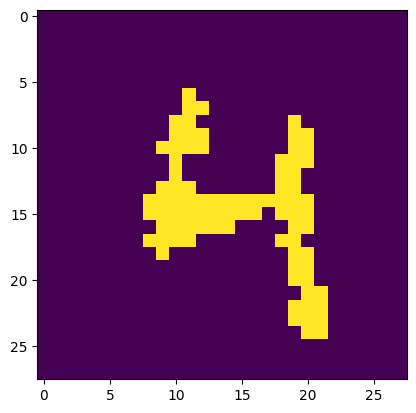

In [7]:
input_batch = next(iter(train_loader))[0][0,:].unsqueeze(0)
input_batch = input_batch.to(device)
plt.imshow(input_batch[0, :].cpu().detach().squeeze().numpy())

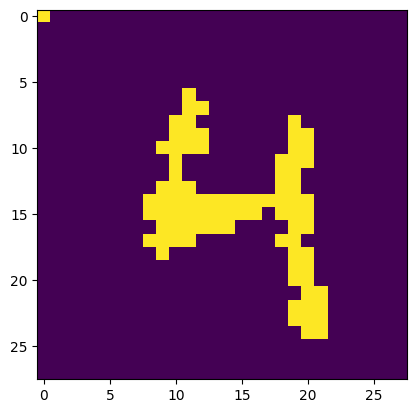

In [20]:
test = input_batch.clone()
test[:, :, 0, 0] = 1
plt.imshow(test.cpu().detach().squeeze().numpy())

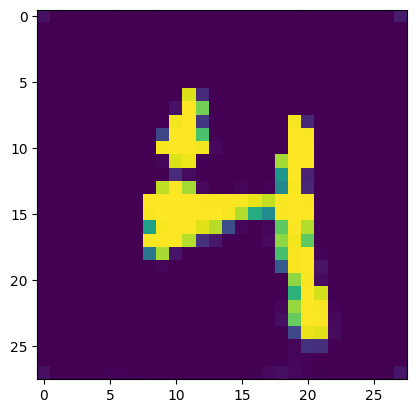

In [8]:
plt.imshow(model(input_batch)[0, :].cpu().detach().squeeze().numpy())

In [36]:
def important_pixels(input_batch: torch.Tensor, model: torchvision.models.segmentation.fcn.FCN, device: torch.device, coordinates: typing.Tuple[int, int]) -> typing.Set[typing.Tuple[int,int]]:
    model = model.to(device)
    input_batch = input_batch.to(device)

    batch_size, _, h, w = input_batch.shape
    model.eval()

    result = set()

    max_value = torch.max(input_batch)
    min_value = torch.min(input_batch)

    with torch.no_grad():
        original_out = model(input_batch)
        original_pixel_value = original_out[:, :, coordinates[0], coordinates[1]]

    for i in range(w):
        for j in range(h):
            image_min = input_batch.clone()
            image_max = input_batch.clone()
            image_min[:, :, i, j] = min_value
            image_max[:, :, i, j] = max_value
            with torch.no_grad():
                min_out = model(image_min)
                max_out = model(image_max)
            
            if not torch.allclose(original_pixel_value, min_out[:, :, coordinates[0], coordinates[1]]) or \
               not torch.allclose(original_pixel_value, max_out[:, :, coordinates[0], coordinates[1]]):
                result.add((i, j))
    
    return result 

In [37]:
input_batch[0, :].shape

torch.Size([1, 28, 28])

In [38]:
checked_pixel = (0, 0)
pixels = important_pixels(input_batch, model, device, checked_pixel)

In [39]:
pixels

{(0, 0),
 (0, 1),
 (0, 2),
 (0, 3),
 (0, 4),
 (0, 5),
 (0, 6),
 (1, 0),
 (1, 1),
 (1, 2),
 (1, 3),
 (1, 4),
 (1, 5),
 (1, 6),
 (1, 7),
 (2, 0),
 (2, 1),
 (2, 2),
 (2, 3),
 (2, 4),
 (2, 5),
 (2, 6),
 (2, 7),
 (3, 0),
 (3, 1),
 (3, 2),
 (3, 3),
 (3, 4),
 (3, 5),
 (3, 6),
 (3, 7),
 (4, 0),
 (4, 1),
 (4, 2),
 (4, 3),
 (4, 4),
 (4, 5),
 (4, 6),
 (4, 7),
 (5, 0),
 (5, 1),
 (5, 2),
 (5, 3),
 (5, 4),
 (5, 5),
 (5, 6),
 (5, 7),
 (6, 0),
 (6, 1),
 (6, 2),
 (6, 3),
 (6, 4),
 (6, 5),
 (6, 6),
 (6, 7),
 (7, 0),
 (7, 1),
 (7, 3),
 (7, 4),
 (7, 5),
 (7, 6),
 (7, 7)}

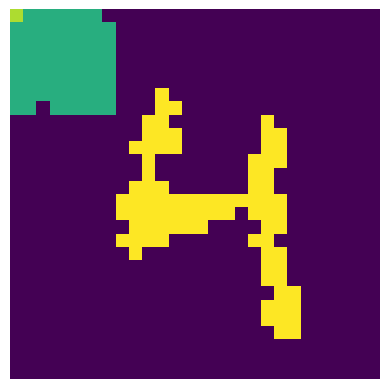

In [40]:
input_image_numpy = input_batch[0, :].cpu().detach().squeeze().numpy()

for pixel in pixels:
    input_image_numpy[pixel[0], pixel[1]] = 0.25

input_image_numpy[checked_pixel[0], checked_pixel[1]] = 0.75

plt.imshow(input_image_numpy)
plt.axis("off")
plt.show()